# PROCESO RESTAURACIÓN DATASET

Dadas las observaciones realizadas en el notebook ***análisis_problema1***, se tomaron las siguientes decisiones:
1. Eliminar la zona de Ucrania (análisis realizado en dicho notebook).
2. Crear puntos de no incendio en el Norte de África.
3. Crear puntos de no incendio en Bielorrusia.
4. Crear puntos de no incendio alrededor de los incendios localizados en Rusia.
5. Eliminar puntos de no incendio para no desbalancear aún más el dataset que tenemos.

In [1]:
from extraccion import minioFunctions as mf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from extraccion import filtros_no_incendio
from extraccion import puntos_no_incendio as ps

In [2]:
l_f = []
for k in [2022, 2023,2024, 2025]:
    print(f"Analizando el año {k}:")
    dataf = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/cleaned/modelo_General_{k}.parquet", type="df")
    l_f.append(dataf)
dataFrame = pd.concat(l_f, ignore_index=True)
df_final = dataFrame.copy()

cliente = mf.crear_cliente()

Analizando el año 2022:
Dataframe importado correctamente
Analizando el año 2023:
Dataframe importado correctamente
Analizando el año 2024:
Dataframe importado correctamente
Analizando el año 2025:
Dataframe importado correctamente


**1.Eliminar zona de Ucrania**

Geodataframe importado correctamente
Geodataframe importado correctamente


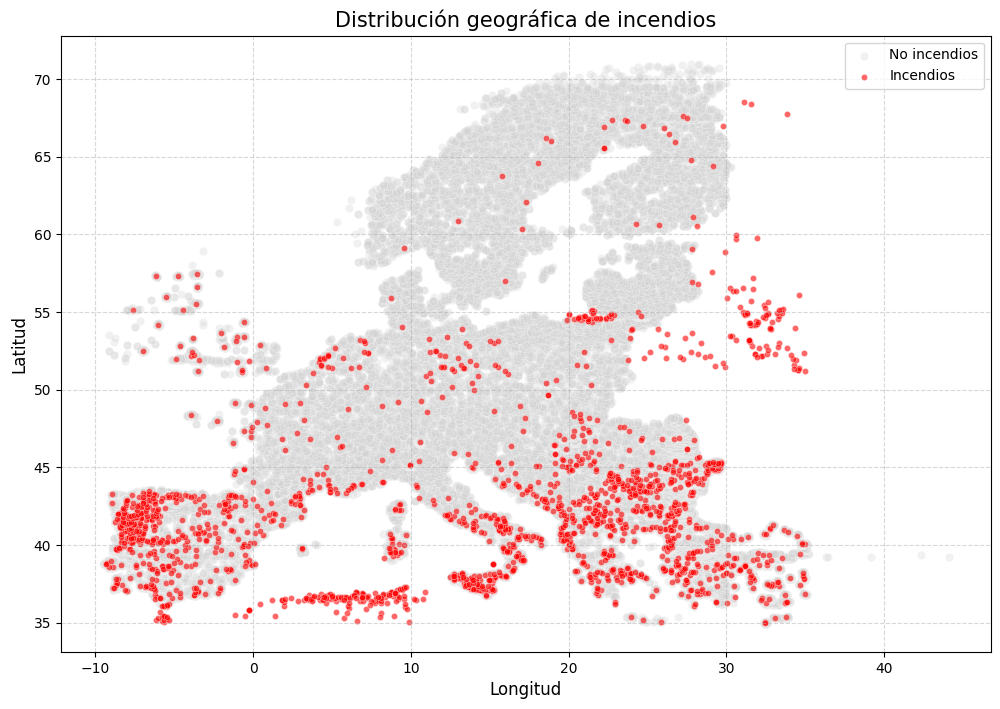

In [ ]:
df_ucrania = filtros_no_incendio.filtrar_zona_eliminar("grupo3/raw/Countries/mascara_Ukraine.parquet", df_final, cliente)

df_correcto = ps.eliminarZona("grupo3/raw/Countries/mascara_Ukraine.parquet", df_final, cliente)

#Eliminamos puntos que han quedado ligeramente fuera de la máscara

filtro2 = (df_correcto['lat'] < 48) & (df_correcto['lon'] < 35) & (df_correcto['lat'] > 46) & (df_correcto['lon'] > 28)
df_correcto = df_correcto[~filtro2]

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_correcto[df_correcto['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_correcto[df_correcto['final'] == 1], x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

#mf.subir_fichero(cliente, "grupo3/cleaned/Modelo_Incendios_final.parquet", df_correcto)

**Fichero de incendios:**

In [4]:
df = mf.bajar_fichero(cliente, 'grupo3/cleaned/Modelo_Incendios_final.parquet', 'df')

Dataframe importado correctamente


**2.Crear puntos de no incendio en África:**

Evaluamos los incendios que tenemos en África:

Geodataframe importado correctamente


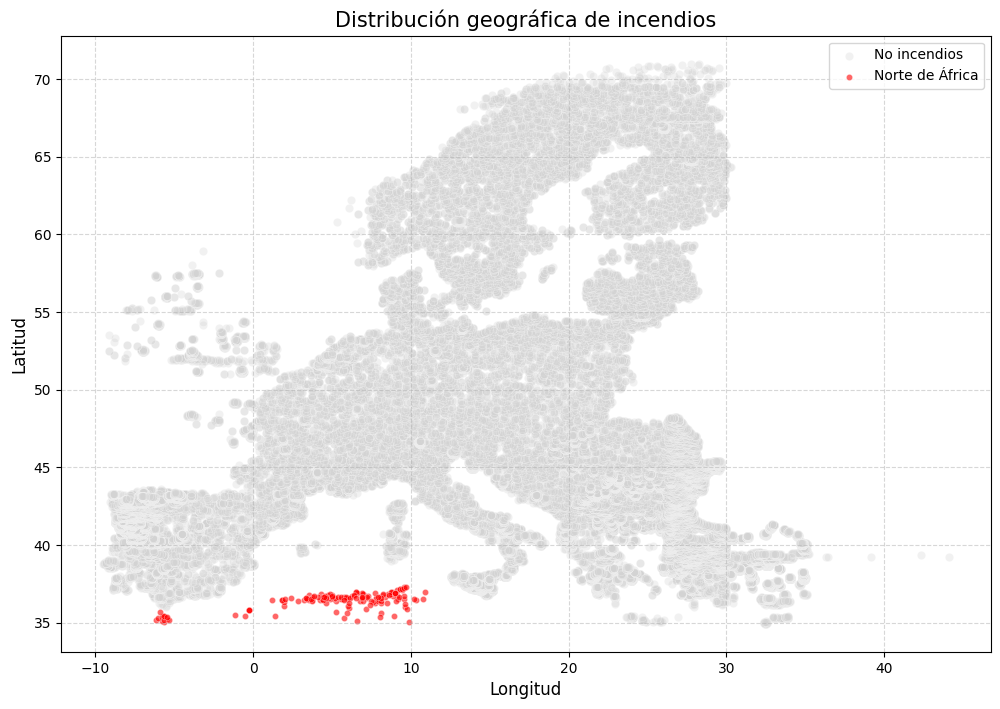

In [ ]:
df_africa = filtros_no_incendio.filtrar_zona_eliminar("grupo3/raw/Countries/mascara_Norte_Africa.parquet", df_final, cliente)

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_africa, x='lon', y='lat', color='red', alpha=0.6, s=20, label='Norte de África')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Geodataframe importado correctamente


<Axes: >

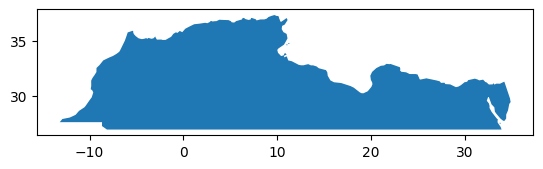

In [6]:
africa = mf.bajar_fichero(cliente, 'grupo3/raw/Countries/mascara_Norte_Africa.parquet', 'gdf')
africa.plot()

### Analisis
Vemos que la máscara cubre mucho más de lo necesario para nuestros puntos, la recortamos

<Axes: >

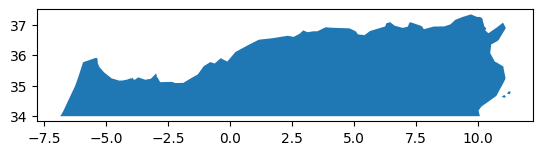

In [7]:
import geopandas as gpd
from shapely.geometry import box


minx, miny, maxx, maxy = africa.total_bounds

caja_limite = box(minx, 34, maxx, maxy)

africa_recortada = gpd.clip(africa, caja_limite)

africa_recortada.plot()

Vemos que esta nueva máscara representa mucho más nuestra intención

In [ ]:
# Subimos la máscara correcta

#mf.subir_fichero(cliente, "grupo3/raw/Countries/mascara_Norte_Africa_recortada.parquet", africa_recortada)

Fichero subido como grupo3/raw/Countries/mascara_Norte_Africa_recortada.parquet


In [9]:
print(f"En África hay {len(df_africa)} incendios")

En África hay 160 incendios


In [ ]:
#print(ps.crearSinteticosUnaZona(df, 'grupo3/raw/Countries/mascara_Norte_Africa_recortada.parquet', 7430))

Geodataframe importado correctamente


c:\Users\lauta\OneDrive\Documents\PROYECTO C++ Y PYTHON\c2526-R3\.venv\Lib\site-packages\rasterio\env.py:166: RasterioDeprecationWarning: Passing abstract session keyword arguments is deprecated. Pass a Rasterio AWSSession object instead.
  warnings.warn(


Geodataframe importado correctamente
Hecho
7279

 Subir a MinIO 
Archivo no subido.
            lat       lon        date
0     35.096820 -5.667117  2022-01-14
1     34.974699 -5.699335  2022-01-14
2     35.066935 -5.591466  2022-01-14
3     35.069710 -5.687393  2022-01-14
4     35.019292 -5.728941  2022-01-14
...         ...       ...         ...
7274  35.826160  5.911370  2022-08-05
7275  35.798178  5.536287  2022-09-09
7276  34.994900  2.564418  2022-10-13
7277  36.025123  2.225664  2022-11-05
7278  34.862652 -1.586205  2022-12-15

[7279 rows x 3 columns]


Observamos si se han creado bien:

Dataframe importado correctamente


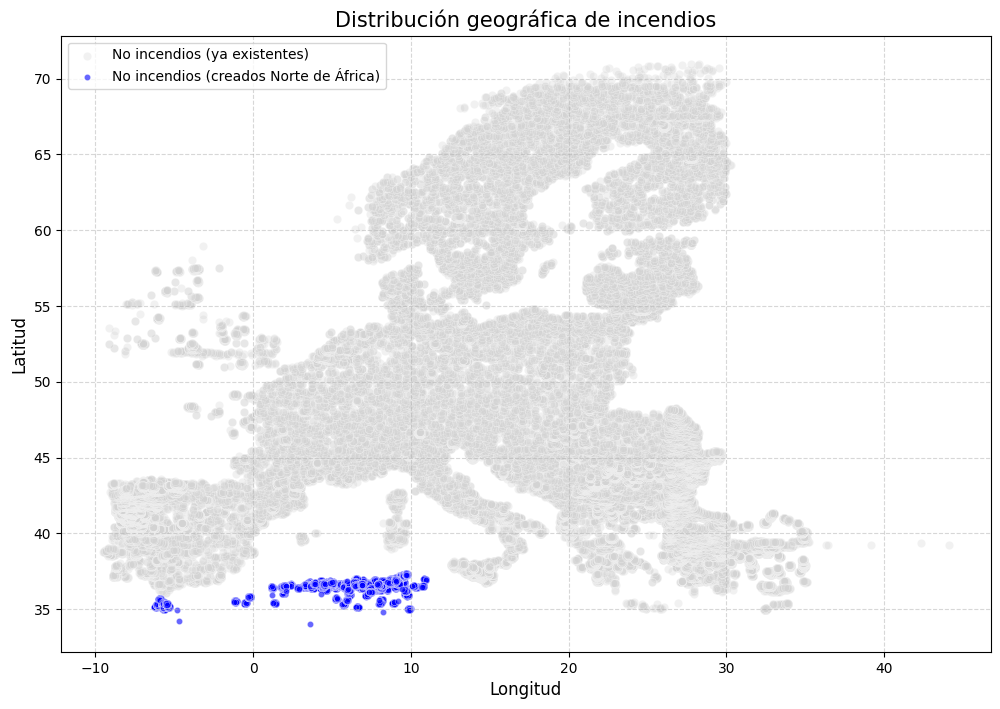

In [11]:
df_creados_africa = mf.bajar_fichero(cliente, "grupo3/raw/No_incendios/Nuevas_Zonas/norte_africa.parquet", "df")

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios (ya existentes)')

sns.scatterplot(data=df_creados_africa, x='lon', y='lat', color='blue', alpha=0.6, s=20, label='No incendios (creados Norte de África)')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [12]:
print(len(df_creados_africa))

7279


**3.Crear puntos de no incendio en Bielorrusia:**

Evaluamos los incendios que tenemos en Bielorrusia:

Geodataframe importado correctamente


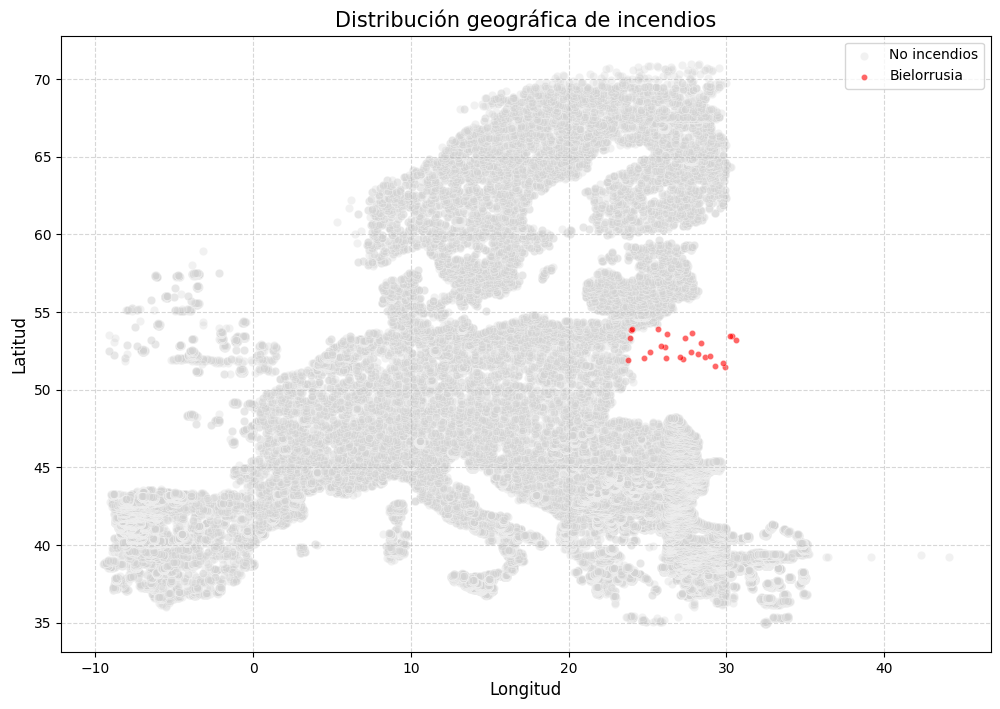

In [ ]:
df_bielorrusia = filtros_no_incendio.filtrar_zona_eliminar("grupo3/raw/Countries/mascara_Belarus.parquet", df, cliente)

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_bielorrusia, x='lon', y='lat', color='red', alpha=0.6, s=20, label='Bielorrusia')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
#print(ps.crearSinteticosUnaZona(df, 'grupo3/raw/Countries/mascara_Belarus.parquet', 838))

Geodataframe importado correctamente


c:\Users\lauta\OneDrive\Documents\PROYECTO C++ Y PYTHON\c2526-R3\.venv\Lib\site-packages\rasterio\env.py:166: RasterioDeprecationWarning: Passing abstract session keyword arguments is deprecated. Pass a Rasterio AWSSession object instead.
  warnings.warn(


Hecho
812

 Subir a MinIO 
Archivo no subido.
           lat        lon        date
0    51.525942  29.872538  2022-01-02
1    51.403821  29.830194  2022-01-02
2    51.496056  29.971968  2022-01-02
3    51.498831  29.845890  2022-02-02
4    51.448413  29.791282  2022-02-02
..         ...        ...         ...
807  53.901857  25.592345  2025-10-25
808  53.883754  25.551919  2025-11-25
809  53.922384  25.563337  2025-11-25
810  53.992037  25.722541  2025-12-25
811  53.998569  25.649941  2025-12-25

[812 rows x 3 columns]


Observamos si se han creado bien:

Dataframe importado correctamente


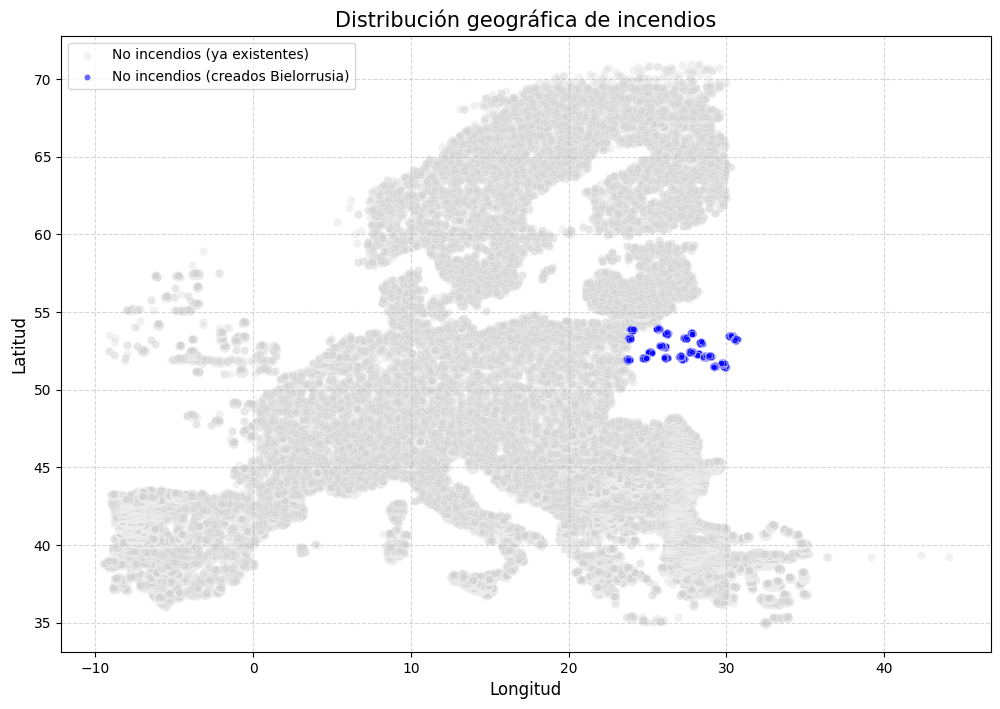

In [15]:
df_creados_bielorrusia = mf.bajar_fichero(cliente, "grupo3/raw/No_incendios/Nuevas_Zonas/belarus.parquet", "df")

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios (ya existentes)')

sns.scatterplot(data=df_creados_bielorrusia, x='lon', y='lat', color='blue', alpha=0.6, s=20, label='No incendios (creados Bielorrusia)')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [16]:
print(len(df_creados_bielorrusia))

812


**4.Crear puntos de no incendio en Rusia:**

Evaluamos los incendios que tenemos en Rusia:

Geodataframe importado correctamente
Geodataframe importado correctamente


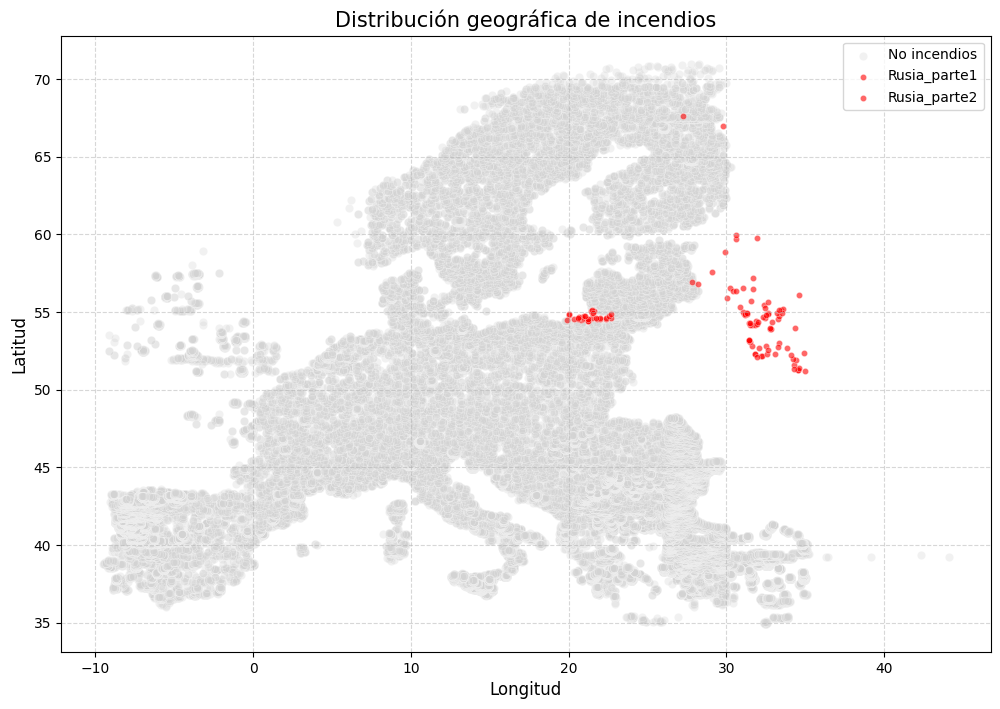

In [ ]:
df_rusia1 = filtros_no_incendio.filtrar_zona_eliminar("grupo3/raw/Countries/mascara_zona_Moscu.parquet", df, cliente)
df_rusia2 = filtros_no_incendio.filtrar_zona_eliminar("grupo3/raw/Countries/mascara_San_Petersburgo.parquet", df, cliente)

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_rusia1, x='lon', y='lat', color='red', alpha=0.6, s=20, label='Rusia_parte1')
sns.scatterplot(data=df_rusia2, x='lon', y='lat', color='red', alpha=0.6, s=20, label='Rusia_parte2')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Geodataframe importado correctamente


<Axes: >

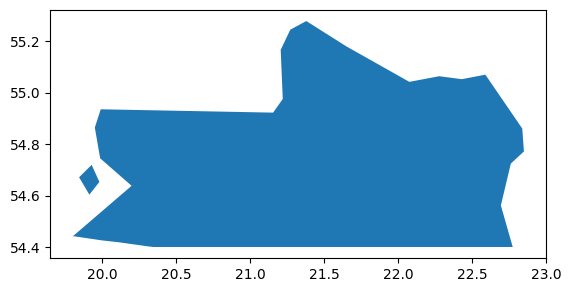

In [18]:
rusia0_plot = mf.bajar_fichero(cliente, "grupo3/raw/Countries/mascara_San_Petersburgo.parquet", 'gdf')
rusia0_plot.plot()

Geodataframe importado correctamente


<Axes: >

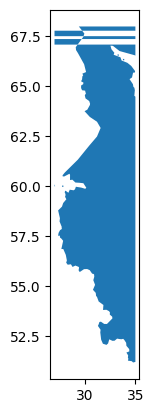

In [19]:
rusia1_plot = mf.bajar_fichero(cliente, "grupo3/raw/Countries/mascara_zona_Moscu.parquet", 'gdf')
rusia1_plot.plot()

<Axes: >

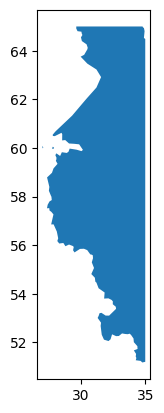

In [20]:
minx, miny, maxx, maxy = rusia1_plot.total_bounds

caja_limite = box(minx, miny, maxx, 65)

rusia1_recortada = gpd.clip(rusia1_plot, caja_limite)

rusia1_recortada.plot()

In [ ]:
#mf.subir_fichero(cliente, "grupo3/raw/Countries/mascara_zona_Moscu_recortada.parquet", rusia1_recortada)

Fichero subido como grupo3/raw/Countries/mascara_zona_Moscu_recortada.parquet


In [ ]:
#print(ps.crearSinteticosUnaZona(df, 'grupo3/raw/Countries/mascara_San_Petersburgo.parquet', 507))

Geodataframe importado correctamente


c:\Users\lauta\OneDrive\Documents\PROYECTO C++ Y PYTHON\c2526-R3\.venv\Lib\site-packages\rasterio\env.py:166: RasterioDeprecationWarning: Passing abstract session keyword arguments is deprecated. Pass a Rasterio AWSSession object instead.
  warnings.warn(


Hecho
476

 Subir a MinIO 
Archivo no subido.
           lat        lon        date
0    54.519977  20.762666  2022-01-28
1    54.397856  20.717283  2022-01-28
2    54.490091  20.869230  2022-01-28
3    54.492866  20.734106  2022-02-28
4    54.442448  20.675580  2022-02-28
..         ...        ...         ...
471  54.880093  22.553433  2025-08-09
472  54.898523  22.672917  2025-09-09
473  54.885780  22.614301  2025-10-09
474  54.775578  22.582434  2025-11-09
475  54.807885  22.558942  2025-12-09

[476 rows x 3 columns]


In [ ]:
#print(ps.crearSinteticosUnaZona(df, 'grupo3/raw/Countries/mascara_zona_Moscu_recortada.parquet', 2297))

Geodataframe importado correctamente


c:\Users\lauta\OneDrive\Documents\PROYECTO C++ Y PYTHON\c2526-R3\.venv\Lib\site-packages\rasterio\env.py:166: RasterioDeprecationWarning: Passing abstract session keyword arguments is deprecated. Pass a Rasterio AWSSession object instead.
  warnings.warn(


Geodataframe importado correctamente
Hecho
2228

 Subir a MinIO 
Archivo no subido.
            lat        lon        date
0     52.360292  31.756523  2022-01-16
1     52.238171  31.713384  2022-01-16
2     52.330406  31.857815  2022-02-16
3     52.333181  31.729375  2022-02-16
4     52.282763  31.673744  2022-03-16
...         ...        ...         ...
2223  61.581223  31.739649  2022-08-25
2224  59.621030  31.193593  2022-09-23
2225  56.441770  30.194996  2022-10-11
2226  56.510506  29.276968  2022-11-19
2227  60.997114  29.232182  2022-12-03

[2228 rows x 3 columns]


Observamos si los hemos creado bien:

Dataframe importado correctamente
Dataframe importado correctamente


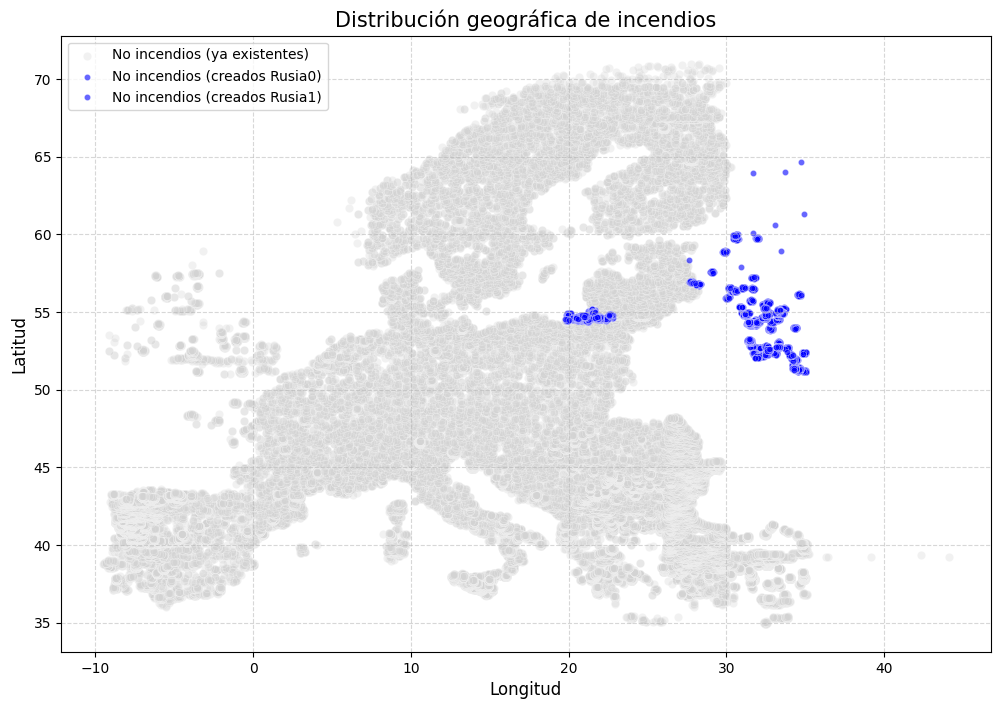

In [24]:
df_creados_rusia0 = mf.bajar_fichero(cliente, "grupo3/raw/No_incendios/Nuevas_Zonas/rusia0.parquet", "df")
df_creados_rusia1 = mf.bajar_fichero(cliente, "grupo3/raw/No_incendios/Nuevas_Zonas/rusia1.parquet", "df")

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios (ya existentes)')

sns.scatterplot(data=df_creados_rusia0, x='lon', y='lat', color='blue', alpha=0.6, s=20, label='No incendios (creados Rusia0)')
sns.scatterplot(data=df_creados_rusia1, x='lon', y='lat', color='blue', alpha=0.6, s=20, label='No incendios (creados Rusia1)')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Contamos el número de puntos que hay actualmente por zona:**

In [25]:
print(ps.contarSinteticosPorArea(df))

Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
G

### Quitar puntos ya creados
Este proceso se debe a la hora de intentar evitar el sesgo por estos datos previamente adquiridos.
Al no haberse producido falsos puntos cercanos, eliminaremos equitativamente de cada zona puntos extra que puedan haber.

Para ello se ha calculado cuantos puntos debería haber en cada lugar con el nuevo número de incendios.
Se han creado mayas espaciales y temporales para poder repartirlos equitativamente y se ha comprobado un 
límite de distancia para asegurarnos no quitar puntos cercanos. También para asegurarnos no quitar valores del
mismo día.

Para saber cuantos puntos queremos de cada máscara, realizamos la función anterior. A continuación, por máscara 
necesitaremos saber debemos quitar. Realizamos un primer filtro para saber cuantos hay y quitaremos la diferencia con los 
que queremos tener.

In [4]:
mascarasRegiones = [
        'grupo3/raw/Biogeoregiones/AtlanticRegion.parquet', 'grupo3/raw/Biogeoregiones/BorealRegion.parquet', 'grupo3/raw/Biogeoregiones/MediterraneanRegion.parquet',
        'grupo3/raw/Biogeoregiones/BlackSeaRegion.parquet', 'grupo3/raw/Biogeoregiones/ContinentalRegion.parquet', 'grupo3/raw/Biogeoregiones/MacaronesianRegion.parquet',
        'grupo3/raw/Biogeoregiones/PannonianRegion.parquet', 'grupo3/raw/Biogeoregiones/SteppicRegion.parquet', 'grupo3/raw/Biogeoregiones/AnatolianRegion.parquet',
        'grupo3/raw/Biogeoregiones/ArcticRegion.parquet', 'grupo3/raw/Biogeoregiones/AlpineRegion.parquet']

In [ ]:
l_f = []
for k in [2022, 2023,2024, 2025]:
    print(f"Analizando el año {k}:")
    dataf = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/cleaned/modelo_General_{k}.parquet", type="df")
    l_f.append(dataf)
dataFrame = pd.concat(l_f, ignore_index=True)
df_final = dataFrame.copy()

cliente = mf.crear_cliente()

df_final_incendios = df_final[df_final['final'] == 1]
df_final_no_incendios = df_final[df_final['final'] == 0]

print(len(df_final))

Analizando el año 2022:


In [ ]:
lista_puntos = [
    4216, 7453, 17818, 872, 11139, 22, 1047, 3534, 
    1635, 1229, 2754, 838, 7430, 2297, 507
]

In [ ]:
lista_dataFrames = []
for i,mascara in enumerate(mascarasRegiones):
    num_filas = len(filtros_no_incendio.filtrar_zona_eliminar(mascara, df_final_no_incendios, cliente))
    num = num_filas - lista_puntos[i]
    
    print(f"Número de filas eliminadas para {mascara}: {num}")


    lista_dataFrames.append(ps.puntosParaBorrar(df_final_no_incendios, mascara, num, cliente))

    print(f"Número de filas a eliminar para {mascara}: {len(lista_dataFrames[i])}")

    #mf.subir_fichero(cliente, f"grupo3/raw/No_incendios/Puntos_para_eliminar/puntos_{mascara.split('/')[-1]}", lista_dataFrames[i])
    

#df_puntos_nuevos = pd.concat(lista_dataFrames, ignore_index=True)

Geodataframe importado correctamente
Número de filas eliminadas para grupo3/raw/Biogeoregiones/AtlanticRegion.parquet: 2340
Geodataframe importado correctamente
Puntos seleccionados por año:
date
2022    285
2023    177
2024    209
2025    293
Name: count, dtype: int64
Número de filas a eliminar para grupo3/raw/Biogeoregiones/AtlanticRegion.parquet: 964
Geodataframe importado correctamente
Número de filas eliminadas para grupo3/raw/Biogeoregiones/BorealRegion.parquet: 2496
Geodataframe importado correctamente
Puntos seleccionados por año:
date
2022    331
2023    304
2024    306
2025    334
Name: count, dtype: int64
Número de filas a eliminar para grupo3/raw/Biogeoregiones/BorealRegion.parquet: 1275
Geodataframe importado correctamente
Número de filas eliminadas para grupo3/raw/Biogeoregiones/MediterraneanRegion.parquet: 4758
Geodataframe importado correctamente
Puntos seleccionados por año:
date
2022    336
2023    331
2024    331
2025    334
Name: count, dtype: int64
Número de filas 

In [ ]:
l_f = []
for k in mascarasRegiones:
    print(f"Analizando parquet de la mascara {k}:")
    dataf = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/raw/No_incendios/Puntos_para_eliminar/puntos_{k.split('/')[-1]}", type="df")
    l_f.append(dataf)
dataFrame = pd.concat(l_f, ignore_index=True)
df_eliminar = dataFrame.copy()

print(len(df_eliminar))

Analizando parquet de la mascara grupo3/raw/Biogeoregiones/AtlanticRegion.parquet:
Dataframe importado correctamente
Analizando parquet de la mascara grupo3/raw/Biogeoregiones/BorealRegion.parquet:
Dataframe importado correctamente
Analizando parquet de la mascara grupo3/raw/Biogeoregiones/MediterraneanRegion.parquet:
Dataframe importado correctamente
Analizando parquet de la mascara grupo3/raw/Biogeoregiones/BlackSeaRegion.parquet:
Dataframe importado correctamente
Analizando parquet de la mascara grupo3/raw/Biogeoregiones/ContinentalRegion.parquet:
Dataframe importado correctamente
Analizando parquet de la mascara grupo3/raw/Biogeoregiones/MacaronesianRegion.parquet:
Dataframe importado correctamente
Analizando parquet de la mascara grupo3/raw/Biogeoregiones/PannonianRegion.parquet:
Dataframe importado correctamente
Analizando parquet de la mascara grupo3/raw/Biogeoregiones/SteppicRegion.parquet:
Dataframe importado correctamente
Analizando parquet de la mascara grupo3/raw/Biogeoregi

In [ ]:
print(len(df_final_no_incendios))
df = ps.eliminarPuntosSeleccionados(df_final_no_incendios, df_eliminar)
print(len(df))
df = pd.concat([df_final_incendios, df], ignore_index=True)
print(len(df))

68760
61996
64680


In [ ]:
mf.subir_fichero(cliente, "grupo3/cleaned/Modelo_General_eliminados.parquet", df)

Fichero subido como grupo3/cleaned/Modelo_General_eliminados


#Concatenar físicas
Debido a la longitud y la Api de open-meteo. Realizamos esta extracción por partes y la unimos

In [ ]:
df = []
cliente = mf.crear_cliente()
df.append(mf.bajar_fichero(cliente,"grupo3/raw/Fisicas/norte_africa_2022.parquet","df"))
df.append(mf.bajar_fichero(cliente,"grupo3/raw/Fisicas/norte_africa_2023_2025.parquet","df"))
df_final = pd.concat(df)
len(df_final)
mf.subir_fichero(cliente, "grupo3/raw/Fisicas/norte_africa.parquet",df_final)

Dataframe importado correctamente
Dataframe importado correctamente
Fichero subido como grupo3/raw/Fisicas/norte_africa.parquet
